In [39]:
! pip install tensorflow 


In [19]:
! pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


Data Preprocessing

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [5]:

# Load dataset
data = pd.read_csv("Rainfall.csv")

# Quick check
print(data.head())

print("Dataset Info:")
print(data.info())
print("Missing Values:")
print(data.isnull().sum())


   day  pressure   maxtemp  temparature  mintemp  dewpoint  humidity   cloud   \
0    1     1025.9     19.9         18.3     16.8      13.1         72      49   
1    2     1022.0     21.7         18.9     17.2      15.6         81      83   
2    3     1019.7     20.3         19.3     18.0      18.4         95      91   
3    4     1018.9     22.3         20.6     19.1      18.8         90      88   
4    5     1015.9     21.3         20.7     20.2      19.9         95      81   

  rainfall  sunshine           winddirection  windspeed  
0      yes       9.3                    80.0       26.3  
1      yes       0.6                    50.0       15.3  
2      yes       0.0                    40.0       14.2  
3      yes       1.0                    50.0       16.9  
4      yes       0.0                    40.0       13.7  
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  D

In [6]:
# strip spaces, lowercase, fix common typos
def clean_col(c):
    c2 = c.strip().lower().replace(" ", "_")
    c2 = c2.replace("temparature", "temperature")  # fix typo if present
    return c2

data.columns = [clean_col(c) for c in data.columns]
print("Cleaned columns:", data.columns.tolist())

Cleaned columns: ['day', 'pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed']


In [7]:
expected_numeric = ['day','pressure','maxtemp','temperature','mintemp','dewpoint',
                    'humidity','cloud','rainfall','sunshine','winddirection','windspeed']

# For any expected column present, try to convert to numeric
for col in expected_numeric:
    if col in data.columns:
        # Remove commas and stray characters then coerce to numeric
        data[col] = data[col].astype(str).str.replace(',', '').str.strip()
        # convert yes/no to 1/0 if present
        data[col] = data[col].replace({'yes': 1, 'no': 0, 'Yes':1, 'No':0, 'YES':1, 'NO':0})
        data[col] = pd.to_numeric(data[col], errors='coerce')

C:\Users\admin\AppData\Local\Temp\ipykernel_11860\81493199.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace({'yes': 1, 'no': 0, 'Yes':1, 'No':0, 'YES':1, 'NO':0})


In [8]:
# Inspect missing / types
print("\nDtypes after numeric coercion:")
print(data.dtypes)
print("\nMissing values count:")
print(data.isnull().sum())


Dtypes after numeric coercion:
day                int64
pressure         float64
maxtemp          float64
temperature      float64
mintemp          float64
dewpoint         float64
humidity           int64
cloud              int64
rainfall           int64
sunshine         float64
winddirection    float64
windspeed        float64
dtype: object

Missing values count:
day              0
pressure         0
maxtemp          0
temperature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    1
windspeed        1
dtype: int64


In [9]:
# Numeric columns: fill with mean
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# Non-numeric: fill with placeholder
non_numeric_cols = data.select_dtypes(exclude=[np.number]).columns.tolist()
for col in non_numeric_cols:
    data[col] = data[col].fillna('Unknown')

print("\nAfter filling missing values:")
print(data.isnull().sum())


After filling missing values:
day              0
pressure         0
maxtemp          0
temperature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64


In [10]:
# ---------- Create RainIntensity ----------

# First ensure 'rainfall' exists and is numeric 0/1 (if it's mm amount, keep as-is)
if 'rainfall' not in data.columns:
    raise KeyError("No 'rainfall' column found after cleaning. Columns: " + ", ".join(data.columns))

# If rainfall is binary (0/1) use that; if numeric amount (mm), convert thresholds accordingly.
def rain_intensity(row):
    rf = row.get('rainfall', np.nan)
    hum = row.get('humidity', np.nan)
    cloud = row.get('cloud', np.nan)
    # If rainfall is nan -> treat as no rain
    if pd.isna(rf) or rf == 0:
        return 0
    # If rainfall seems like amount (e.g., >2 mm is heavy)
    # We'll check typical numeric range to decide path:
    if rf > 2:  # treat as amount (mm) => define thresholds
        if rf <= 2:
            return 1
        else:
            return 2
    # else if rf == 1 likely binary flag -> use humidity/cloud to split light/heavy
    if rf == 1:
        # fallback defaults if humidity/cloud missing
        hum_val = hum if not pd.isna(hum) else 0
        cloud_val = cloud if not pd.isna(cloud) else 0
        if hum_val < 80 or cloud_val < 70:
            return 1
        else:
            return 2
    # default fallback
    return 0

data['RainIntensity'] = data.apply(rain_intensity, axis=1)
print("\nValue counts for RainIntensity:")
print(data['RainIntensity'].value_counts())


Value counts for RainIntensity:
RainIntensity
2    159
0    117
1     90
Name: count, dtype: int64


In [11]:
# ---------- Simulate RainSensor ----------

def simulate_sensor(row):
    r = row['RainIntensity']
    if r == 0:
        return np.random.randint(0, 200)
    elif r == 1:
        return np.random.randint(200, 600)
    else:
        return np.random.randint(600, 1023)

data['RainSensor'] = data.apply(simulate_sensor, axis=1)
print("\nSample RainSensor values:")
print(data[['RainIntensity','RainSensor']].head(10))



Sample RainSensor values:
   RainIntensity  RainSensor
0              1         591
1              2         784
2              2         909
3              2         835
4              2         946
5              1         237
6              0         160
7              0         155
8              0           7
9              2         967


In [12]:
# ---------- Final check ----------

print("\nFinal columns and dtypes:")
print(data.dtypes)
print("\nHead:")
print(data.head())


Final columns and dtypes:
day                int64
pressure         float64
maxtemp          float64
temperature      float64
mintemp          float64
dewpoint         float64
humidity           int64
cloud              int64
rainfall           int64
sunshine         float64
winddirection    float64
windspeed        float64
RainIntensity      int64
RainSensor         int64
dtype: object

Head:
   day  pressure  maxtemp  temperature  mintemp  dewpoint  humidity  cloud  \
0    1    1025.9     19.9         18.3     16.8      13.1        72     49   
1    2    1022.0     21.7         18.9     17.2      15.6        81     83   
2    3    1019.7     20.3         19.3     18.0      18.4        95     91   
3    4    1018.9     22.3         20.6     19.1      18.8        90     88   
4    5    1015.9     21.3         20.7     20.2      19.9        95     81   

   rainfall  sunshine  winddirection  windspeed  RainIntensity  RainSensor  
0         1       9.3           80.0       26.3         

Model Training

In [13]:

# Feature Selection

X = data.drop(columns=['day', 'RainIntensity'])  # drop day and target
y = data['RainIntensity']

print("Features:", X.columns.tolist())
print("Target:", y.unique())


Features: ['pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed', 'RainSensor']
Target: [1 2 0]


In [35]:
# Prepare data for Neural Network

# X_train_scaled, X_test_scaled, y_train, y_test are already ready from your previous preprocessing
import tensorflow as tf
import numpy as np

# Ensure labels are integer type
y_train = y_train.astype(np.int32)
y_test = y_test.astype(np.int32)


In [36]:
# Build a lightweight Neural Network

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Small NN for microcontroller deployment
nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes: 0-No,1-Light,2-Heavy
])

nn_model.compile(optimizer='adam', 
                 loss='sparse_categorical_crossentropy', 
                 metrics=['accuracy'])

nn_model.summary()


c:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 995 (3.89 KB)

 Trainable params: 995 (3.89 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Train the Neural Network

history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=8,
    verbose=1
)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6738 - loss: 0.8743 - val_accuracy: 0.6441 - val_loss: 0.8976
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8197 - loss: 0.6375 - val_accuracy: 0.7119 - val_loss: 0.7435
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8712 - loss: 0.4885 - val_accuracy: 0.7458 - val_loss: 0.6305
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8884 - loss: 0.3799 - val_accuracy: 0.8136 - val_loss: 0.5103
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9356 - loss: 0.2979 - val_accuracy: 0.8983 - val_loss: 0.3908
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9657 - loss: 0.2382 - val_accuracy: 0.9322 - val_loss: 0.2974
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9742 - loss: 0.1895 - val_accuracy: 0.9661 - val_loss: 0.2136
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9785 - loss: 0.1525 - val_accuracy: 0.9661 - val_los

In [38]:
# Evaluate on test set

loss, accuracy = nn_model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy:.2f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0164
Test Accuracy: 1.00


In [39]:
# Save as TFLite model for ESP32

# Save Keras model first
nn_model.save("rain_nn_model.h5")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(nn_model)
tflite_model = converter.convert()

# Save TFLite model
with open("rain_nn_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved: rain_nn_model.tflite")


INFO:tensorflow:Assets written to: C:\Users\admin\AppData\Local\Temp\tmpgn362_as\assets


INFO:tensorflow:Assets written to: C:\Users\admin\AppData\Local\Temp\tmpgn362_as\assets


Saved artifact at 'C:\Users\admin\AppData\Local\Temp\tmpgn362_as'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2454948789968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454953822336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454953828320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454953827792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454953827968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454953829376: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved: rain_nn_model.tflite


Test TFLite

In [63]:
# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="rain_nn_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test first row
test_input = X_test_scaled[0].reshape(1, -1).astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])
predicted_class = np.argmax(output)
print("Predicted class:", predicted_class, "Actual class:", y_test.iloc[0])


Predicted class: 1 Actual class: 1


c:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Visualization & Analysis

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

C:\Users\admin\AppData\Local\Temp\ipykernel_11860\2657797311.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette="viridis")


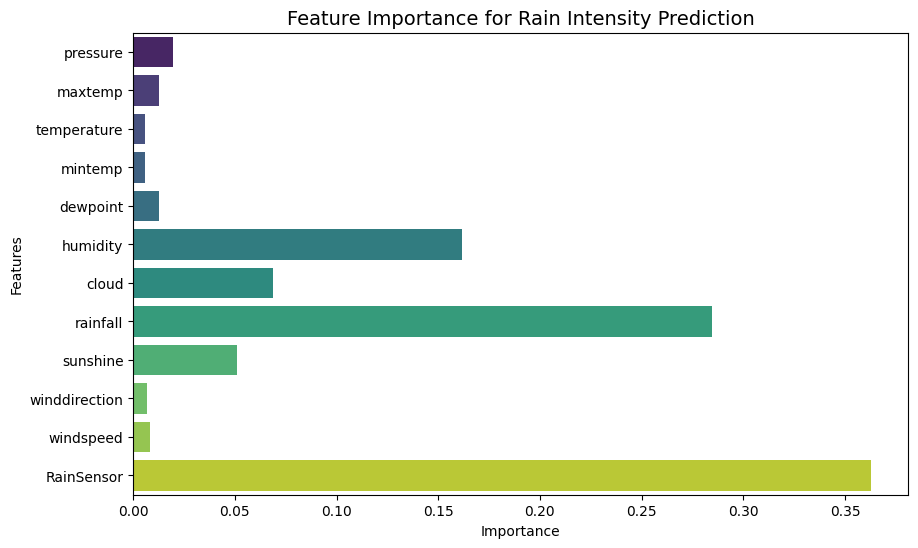

In [64]:
# Plot feature importances

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Feature Importance for Rain Intensity Prediction", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [65]:

# Generate predictions from TFLite model

predictions = []
for i in range(len(X_test_scaled)):
    test_input = X_test_scaled[i].reshape(1, -1).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], test_input)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    predicted_class = np.argmax(output)
    predictions.append(predicted_class)

# Add predictions to DataFrame (only for test samples)

# Copy X_test into a DataFrame
test_df = X_test.copy()

# Add actual target
test_df['actual_rain'] = y_test.values

# Add predicted target
test_df['predicted_rain'] = predictions   # Make sure 'predictions' is non-empty

# Quick check
print(test_df[['actual_rain','predicted_rain']].head())

     actual_rain  predicted_rain
208            1               1
330            0               0
2              2               2
332            0               0
166            1               1


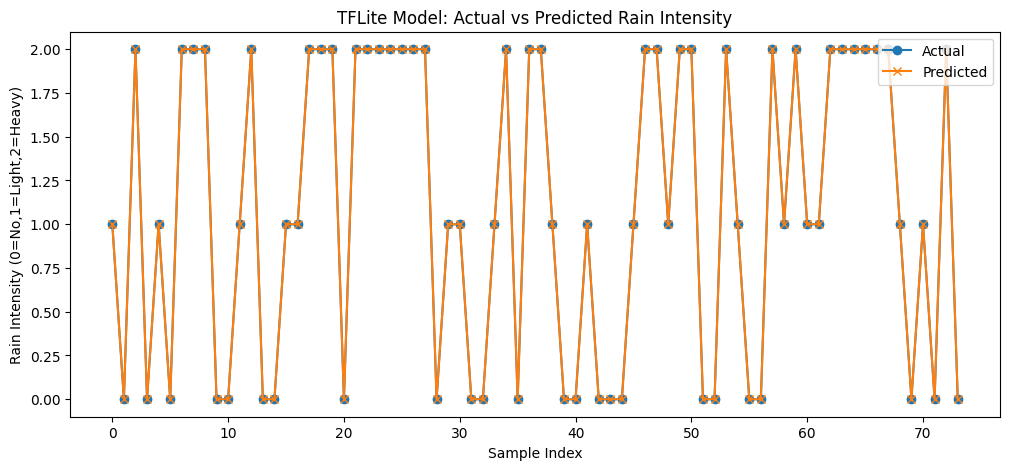

In [66]:
# Plot Actual vs Predicted

plt.figure(figsize=(12,5))
plt.plot(test_df['actual_rain'].values, label='Actual', marker='o')
plt.plot(test_df['predicted_rain'].values, label='Predicted', marker='x')
plt.title("TFLite Model: Actual vs Predicted Rain Intensity")
plt.xlabel("Sample Index")
plt.ylabel("Rain Intensity (0=No,1=Light,2=Heavy)")
plt.legend()
plt.show()

In [67]:
data.columns = [c.strip().lower().replace("temparature", "temperature").replace(" ", "_") for c in data.columns]

# Check the cleaned names
print(data.columns.tolist())

['day', 'pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed', 'predicted_rain']


C:\Users\admin\AppData\Local\Temp\ipykernel_11860\1842806525.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='predicted_rain', y='humidity', data=data, palette='coolwarm')


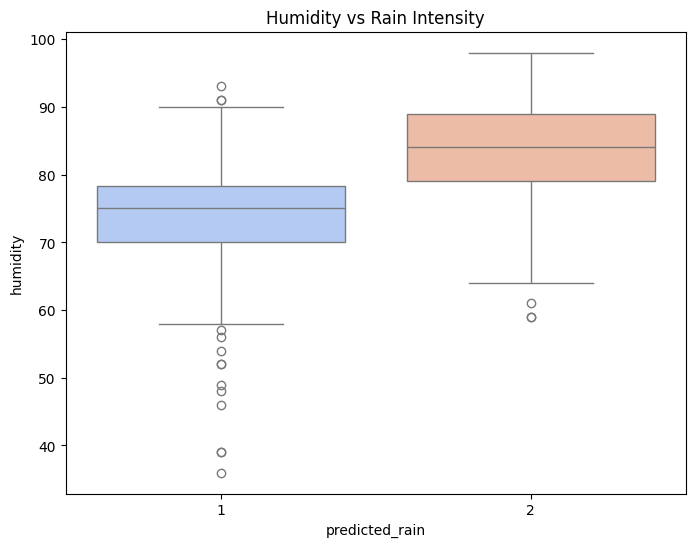

In [ ]:
# Humidity vs Rain

plt.figure(figsize=(8,6))
sns.boxplot(x='predicted_rain', y='humidity', data=data, palette='coolwarm')
plt.title("Humidity vs Rain Intensity")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_11860\3802045970.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data, x='predicted_rain', bins=30, palette='Set2', kde=True)


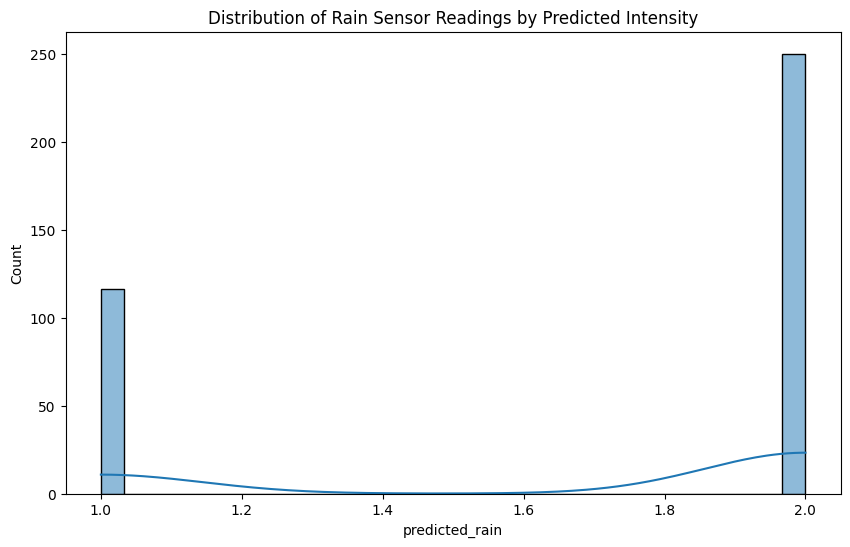

In [70]:
# Rain Sensor distribution by intensity

plt.figure(figsize=(10,6))
sns.histplot(data, x='predicted_rain', bins=30, palette='Set2', kde=True)
plt.title("Distribution of Rain Sensor Readings by Predicted Intensity")
plt.show()

Export Model (for IoT Simulation)

In [26]:
# Save the Model

import joblib

# Save model
joblib.dump(model, "rain_intensity_model.pkl")

print("Model saved as rain_intensity_model.pkl")


Model saved as rain_intensity_model.pkl


In [27]:
# Load Model Back To Test

loaded_model = joblib.load("rain_intensity_model.pkl")
loaded_pred = loaded_model.predict(X_test_scaled)

In [28]:
# Define mapping dictionary
intensity_labels = {
    0: "No Rain",
    1: "Light Rain",
    2: "Heavy Rain"
}

# Test prediction on first 5 rows

sample = X.head(5)
sample_scaled = scaler.transform(sample)   # scale input same as training

predictions = loaded_model.predict(sample_scaled)
# Map numeric predictions to labels
predicted_labels = [intensity_labels[p] for p in predictions]

print("Predictions (numeric):", predictions)
print("Predictions (labels):", predicted_labels)

Predictions (numeric): [1 2 2 2 2]
Predictions (labels): ['Light Rain', 'Heavy Rain', 'Heavy Rain', 'Heavy Rain', 'Heavy Rain']
